## Sentiment analysis with Transformers and PyTorch

#### If running on Colab, enable GPU runtime.

In [2]:
# IMPORT LIBRARIES FOR TRANSFORMERS-BASED APPROACH

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
import math
import re
from dataclasses import dataclass
from typing import Dict, List, Any


import torch
from torch.utils.data import DataLoader


from datasets import Dataset, DatasetDict
from transformers import (
DistilBertTokenizerFast,
DistilBertForSequenceClassification,
DataCollatorWithPadding,
TrainingArguments,
Trainer,
EarlyStoppingCallback,
set_seed
)

%pip install evaluate --quiet
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import evaluate




Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# CONFIGURATION
SEED = 42
set_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


In [ ]:
# DATA LOADING AND PREPROCESSING

# Training on local CPU
df = pd.read_csv('../data/Reviews.csv')


# Keep only relevant columns and drop NA values
print('Original rows:', len(df))
# Keep relevant columns and drop NA
df = df[['Score', 'Text']].dropna()
print('After dropping NA:', len(df))



Original rows: 568454
After dropping NA: 568454


In [4]:
# DISPLAY FIRST 3 ROWS AS DICTIONARIES

print(df.head(3).to_dict(orient='records'))

[{'Score': 5, 'Text': 'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'}, {'Score': 1, 'Text': 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'}, {'Score': 4, 'Text': 'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out

In [5]:
# DATA PREPROCESSING

def clean_text(text: str) -> str:
    """
    Cleans a text string by:
    - Removing HTML tags
    - Removing URLs
    - Removing extra whitespace

    Args:
        text (str): Input text.

    Returns:
        str: Cleaned text.
    """
    # Ensure input is string
    text = str(text)

    # Remove HTML tags (regex)
    text = re.sub(r'<[^>]+>', '', text)

    # Alternatively, use BeautifulSoup for more complex HTML
    # text = BeautifulSoup(text, "html.parser").get_text()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text, flags=re.MULTILINE)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['Text'] = df['Text'].astype(str).apply(clean_text)

# Remove empty or whitespace-only texts
initial_count = len(df)
df = df[df['Text'].str.strip().astype(bool)]
final_count = len(df)

print(f'Rows before cleaning: {initial_count}')
print(f'Rows after removing empty texts: {final_count}')
print(f'Removed {initial_count - final_count} empty rows')


Rows before cleaning: 568454
Rows after removing empty texts: 568454
Removed 0 empty rows


In [6]:
# Optional: sample for faster experiments (uncomment to debug quickly)
df = df.sample(frac=0.1, random_state=42)
df.shape

(56845, 2)

In [8]:
# CONVERT SCORES TO LABELS

# Choose problem type: '3-class' or 'binary'

df = df[df['Score'] != 3]  # For binary classification, remove neutral reviews

PROBLEM_TYPE = 'binary' # options: '3-class' or 'binary'
num_labels = 3 if PROBLEM_TYPE == '3-class' else 2
def score_to_label(score, problem_type=PROBLEM_TYPE):
    if problem_type == '3-class':
        if score <= 2:
            return 0 # negative
        elif score == 3:
            return 1 # neutral
        else:
            return 2 # positive
    else:
        return 0 if score <= 3 else 1 # binary

df['label'] = df['Score'].map(score_to_label)
print(df['label'].value_counts())



label
1    44496
0     8082
Name: count, dtype: int64


In [9]:
# SPLIT DATAFRAME INTO TRAIN, VAL, TEST

train_df, test_df = train_test_split(df, test_size=0.10, stratify=df['label'], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.1111, stratify=train_df['label'], random_state=SEED) # 0.1111*0.9 ~= 0.10 overall


print('Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))

Train: 42062 Val: 5258 Test: 5258


In [10]:
# CREATE HUGGINGFACE DATASET DICTIONARY

dataset = DatasetDict({
'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
'validation': Dataset.from_pandas(val_df.reset_index(drop=True)),
'test': Dataset.from_pandas(test_df.reset_index(drop=True)),
})

In [11]:
# TOKENIZATION

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128 # 128 or 256
BATCH_SIZE = 16 # effective batch size = BATCH_SIZE * grad_accum_steps


tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)


# Tokenize function
def tokenize_fn(batch):
    return tokenizer(batch['Text'], truncation=True, padding=False, max_length=MAX_LENGTH)


# Map
dataset = dataset.map(tokenize_fn, batched=True, remove_columns=['Text', 'Score'])


# Set format for PyTorch
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


print(dataset)

Map:   0%|          | 0/42062 [00:00<?, ? examples/s]

Map:   0%|          | 0/5258 [00:00<?, ? examples/s]

Map:   0%|          | 0/5258 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 42062
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 5258
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 5258
    })
})


In [ ]:
# MODEL INITIALIZATION

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=num_labels,
)
model.to(DEVICE)

# 
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# Metrics
accuracy = evaluate.load('accuracy')
f1_macro = evaluate.load('f1')


label_names = ['negative', 'neutral', 'positive'] if num_labels == 3 else ['negative', 'positive']


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=preds, references=labels)
    f1 = f1_macro.compute(predictions=preds, references=labels, average='macro')
    return {'accuracy': acc['accuracy'], 'f1_macro': f1['f1']}

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# TRAINING SETUP

output_dir = './distilbert_amazon_sentiment'
training_args = TrainingArguments(
output_dir=output_dir,
eval_strategy='epoch',
save_strategy='epoch',
learning_rate=2e-5, # from 5e-5 to 2e-5 for better results
per_device_train_batch_size=BATCH_SIZE,
per_device_eval_batch_size=BATCH_SIZE,
num_train_epochs=3,
weight_decay=0.01, # L2 regularization
logging_steps=200,
load_best_model_at_end=True,
metric_for_best_model='f1_macro',
greater_is_better=True,
save_total_limit=2,
fp16=torch.cuda.is_available(),
)


trainer = Trainer(
model=model,
args=training_args,
train_dataset=dataset['train'],
eval_dataset=dataset['validation'],
tokenizer=tokenizer,
data_collator=data_collator,
compute_metrics=compute_metrics,
callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] 
)





C:\Users\IrfanF\AppData\Local\Temp\ipykernel_9272\1478836723.py:25: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [14]:
# TRAINING

trainer.train()

c:\Users\IrfanF\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.150900,0.129114,0.953975,0.911439
2,0.090800,0.154107,0.957208,0.917785
3,0.056700,0.193118,0.957969,0.919409


c:\Users\IrfanF\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\IrfanF\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=7887, training_loss=0.10727953254851579, metrics={'train_runtime': 15484.5775, 'train_samples_per_second': 8.149, 'train_steps_per_second': 0.509, 'total_flos': 4172644405146048.0, 'train_loss': 0.10727953254851579, 'epoch': 3.0})

c:\Users\IrfanF\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test metrics (HF evaluate): {'eval_loss': 0.22298745810985565, 'eval_accuracy': 0.9534043362495246, 'eval_f1_macro': 0.9109269738922363, 'eval_runtime': 115.2481, 'eval_samples_per_second': 45.623, 'eval_steps_per_second': 2.855, 'epoch': 3.0}


c:\Users\IrfanF\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Classification report:
              precision    recall  f1-score   support

    negative     0.8437    0.8552    0.8494       808
    positive     0.9736    0.9712    0.9724      4450

    accuracy                         0.9534      5258
   macro avg     0.9087    0.9132    0.9109      5258
weighted avg     0.9537    0.9534    0.9535      5258



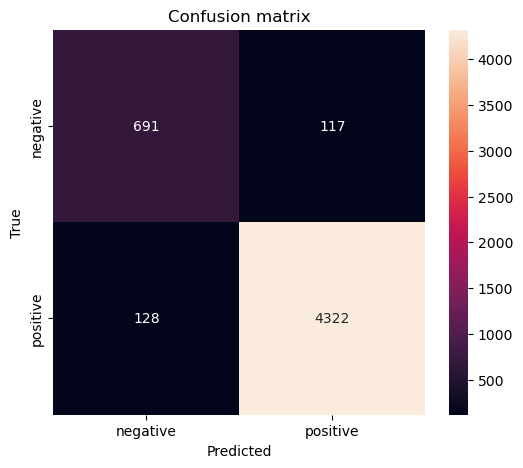

In [15]:
# EVALUATION

metrics = trainer.evaluate(dataset['test'])
print('Test metrics (HF evaluate):', metrics)


# Get predictions for detailed report
preds_output = trainer.predict(dataset['test'])
preds = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids


print('Classification report:')
print(classification_report(labels, preds, target_names=label_names, digits=4))


# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

In [16]:
# SAVE THE TRAINED MODEL AND TOKENIZER

# # Mounting Google Drive (uncomment if using Colab)
# from google.colab import drive
# drive.mount('/content/gdrive')

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print('Saved to', output_dir)

Saved to ./distilbert_amazon_sentiment


In [17]:
# INFERENCE USING THE SAVED MODEL

from transformers import pipeline

# load pipeline from saved model
classifier = pipeline('text-classification', model=output_dir, tokenizer=output_dir, device=0 if DEVICE=='cuda' else -1)
# test examples
examples = [
"This product is fantastic — it arrived quickly and the quality is excellent.",
"Terrible. The food was stale and the packaging was ruined. Won't buy again.",
"It's okay, not great but not bad either."
]
print('Examples:')
for ex in examples:
    print(ex)
    print(classifier(ex, top_k=1))
    print()

Device set to use cpu


Examples:
This product is fantastic — it arrived quickly and the quality is excellent.
[{'label': 'LABEL_1', 'score': 0.999771773815155}]

Terrible. The food was stale and the packaging was ruined. Won't buy again.
[{'label': 'LABEL_0', 'score': 0.9976450800895691}]

It's okay, not great but not bad either.
[{'label': 'LABEL_1', 'score': 0.9976847171783447}]



In [4]:
# MODEL QUANTIZATION

import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast, pipeline

# Load the trained model (use the same output_dir from training)
output_dir = '../models/distilbert_sentiment'
model = DistilBertForSequenceClassification.from_pretrained(output_dir)
tokenizer = DistilBertTokenizerFast.from_pretrained(output_dir)

# Get original model file size
original_size = os.path.getsize(output_dir + '/model.safetensors') / (1024**2)
print(f"Original model size: {original_size:.2f} MB")

# Apply dynamic quantization
# This reduces model size by ~4x and speeds up CPU inference by ~2-3x
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},  # Quantize all Linear layers
    dtype=torch.qint8   # Use 8-bit integers instead of 32-bit floats
)

# Save quantized model using torch.save (quantized models can't use save_pretrained)
quantized_output_dir = '../models/distilbert_sentiment_quantized'
os.makedirs(quantized_output_dir, exist_ok=True)

# Save the quantized model as a PyTorch state dict
torch.save(quantized_model.state_dict(), os.path.join(quantized_output_dir, 'quantized_model.pth'))

# Save the config and tokenizer (these are not quantized)
model.config.save_pretrained(quantized_output_dir)
tokenizer.save_pretrained(quantized_output_dir)

print(f"Quantized model saved to: {quantized_output_dir}")
quantized_size = os.path.getsize(quantized_output_dir + '/quantized_model.pth') / (1024**2)
print(f"Quantized model size: {quantized_size:.2f} MB")
print(f"Size reduction: {(1 - quantized_size/original_size)*100:.1f}%")

# Test quantized model
print("\n--- Testing Quantized Model ---")
classifier_quantized = pipeline(
    'text-classification', 
    model=quantized_model, 
    tokenizer=tokenizer,
    device=-1  # CPU only for quantized models
)

# Compare predictions
test_texts = [
    "This product is amazing! Best purchase ever!",
    "Terrible quality, waste of money.",
    "It's okay, nothing special."
]

print("\nPredictions from Quantized Model:")
for text in test_texts:
    result = classifier_quantized(text)[0]
    print(f"Text: {text[:50]}...")
    print(f"  → {result['label']} (confidence: {result['score']:.4f})\n")

Original model size: 255.43 MB


C:\Users\IrfanF\AppData\Local\Temp\ipykernel_10744\3236630417.py:17: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(
Device set to use cpu
Device set to use cpu


Quantized model saved to: ../models/distilbert_sentiment_quantized
Quantized model size: 132.29 MB
Size reduction: 48.2%

--- Testing Quantized Model ---

Predictions from Quantized Model:
Text: This product is amazing! Best purchase ever!...
  → LABEL_1 (confidence: 0.9998)

Text: Terrible quality, waste of money....
  → LABEL_0 (confidence: 0.9972)

Text: It's okay, nothing special....
  → LABEL_1 (confidence: 0.9462)

